<a href="https://colab.research.google.com/github/sjlee53/ESAA-submission/blob/main/YB_0918(1)_exercises_chipotle_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# set this so the graphs open internally
%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv).

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv',sep='\t')
df.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


### Step 3. Assign it to a variable called chipo.

In [3]:
chipo=url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv'
chipo = pd.read_csv(url, sep='\t')

### Step 4. See the first 10 entries

In [4]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### Step 5. Create a histogram of the top 5 items bought

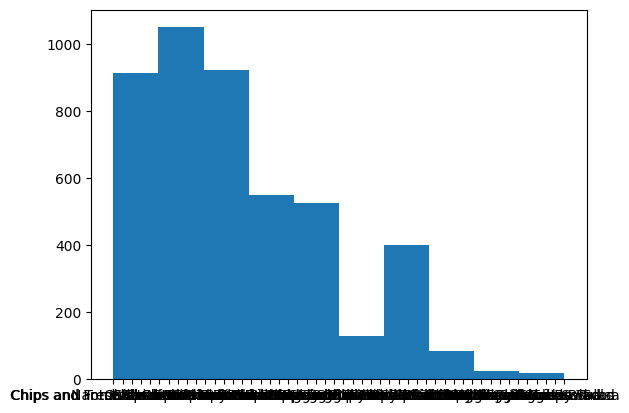

In [5]:
plt.hist(df.item_name)
plt.show()

### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

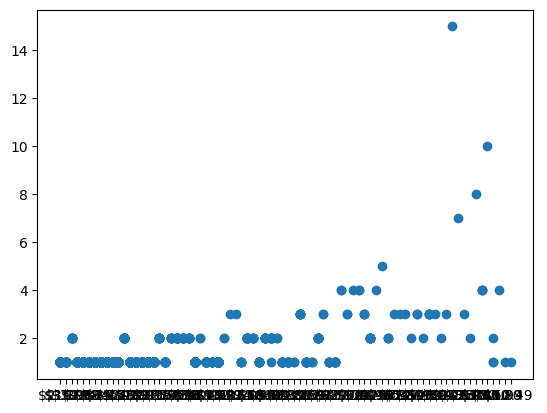

In [6]:
plt.scatter(df.item_price,df.quantity)
plt.show()

### Step 7. BONUS: Create a question and a graph to answer your own question.

Q. 과카몰리 추가 비용은 메뉴마다 다를까?



In [7]:
import numpy as np

# $ 떼고 숫자로 → 1개당 가격
chipo['price'] = chipo['item_price'].str.slice(1).astype(float)
chipo['unit_price'] = chipo['price'] / chipo['quantity']

# 과카몰리가 들어갔는지
chipo['guac'] = chipo['choice_description'].fillna('').str.contains('Guacamole')

main = ['Chicken Bowl', 'Chicken Burrito', 'Steak Bowl', 'Steak Burrito', 'Veggie Bowl']
sub = chipo[chipo['item_name'].isin(main)]

표 = sub.pivot_table(index='item_name', columns='guac',
                    values='unit_price', aggfunc='mean').loc[main]
표.columns = ['no_guac', 'guac']
표['diff'] = 표['guac'] - 표['no_guac']
표.round(2)

,no_guac,guac,diff
item_name,,,
Chicken Bowl,8.68,11.20,2.52
Chicken Burrito,8.66,11.17,2.51
Steak Bowl,9.14,11.71,2.57
Steak Burrito,9.11,11.68,2.57
Veggie Bowl,8.65,11.23,2.58


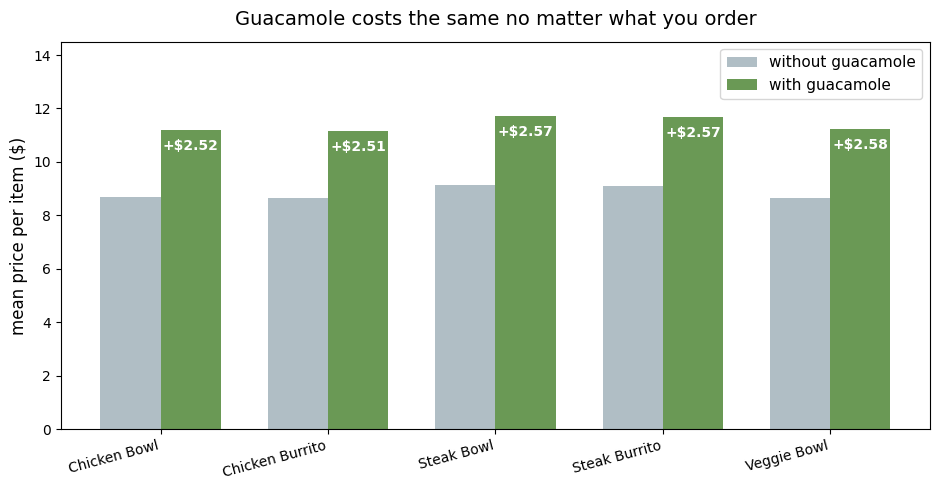

In [8]:
x = np.arange(len(main))
w = 0.36

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.bar(x - w/2, 표['no_guac'], w, label='without guacamole', color='#b0bec5')
ax.bar(x + w/2, 표['guac'], w, label='with guacamole', color='#6a9955')

for i in x:
    ax.text(i + w/2, 표['guac'].iloc[i] - 0.75, f"+${표['diff'].iloc[i]:.2f}",
            ha='center', fontsize=10, fontweight='bold', color='white')

ax.set_xticks(x)
ax.set_xticklabels(main, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('mean price per item ($)', fontsize=12)
ax.set_title('Guacamole costs the same no matter what you order', fontsize=14, pad=12)
ax.set_ylim(0, 14.5)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

메뉴가 뭐든 과카몰리는 약 $2.55이다. 최소 $2.51, 최대 $2.58 — 편차가 7센트밖에 안된다